# EDA: Price & Area Distributions + Feature Analysis

Phân tích chi tiết về phân bố giá, diện tích và các đặc trưng bất động sản chính.
- **Data**: Raw_Features từ Supabase (fallback: model_training_data.csv)
- **Features**: area_m2, width_m, length_m, num_floors, num_bedrooms, road_width_m
- **Focus**: Price distribution, area distribution, feature correlations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import sys
warnings.filterwarnings('ignore')

# Add project path
sys.path.insert(0, '../../')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Load data - try Supabase first, fallback to local
print('[Data Loading]')
try:
    from pipeline.supabase_handler import fetch_csv_from_supabase
    df = fetch_csv_from_supabase("Raw_Features")
    if len(df) == 0:
        raise ValueError("No records fetched from Supabase")
    data_source = "Supabase (Raw_Features)"
except Exception as e:
    print(f'  [Warning] {e}')
    print('  Using local fallback: model_training_data.csv')
    df = pd.read_csv('../../data/processed/model_training_data.csv')
    data_source = "Local (model_training_data.csv)"

print(f'  ✓ Data source: {data_source}')
print(f'  ✓ Dataset shape: {df.shape}')
print(f'  ✓ Loaded {df.shape[0]:,} properties with {df.shape[1]} features')

[Data Loading]
[Supabase] Fetching data from table: Raw_Features
[Supabase] Fetched 12832 rows from Raw_Features

  ✓ Data source: Supabase (Raw_Features)
  ✓ Dataset shape: (12832, 46)
  ✓ Loaded 12,832 properties with 46 features


## 1. Dataset Overview

In [2]:
# Basic statistics
print('=== DATASET INFO ===')
print(f'Total records: {len(df):,}')
print(f'Total features: {df.shape[1]}')
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

# Missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f'\nMissing values:\n{missing[missing > 0]}')
else:
    print('\nNo missing values ✓')

# Data types
print(f'\nData types:\n{df.dtypes.value_counts()}')

=== DATASET INFO ===
Total records: 12,832
Total features: 46

Memory usage: 15.19 MB

Missing values:
link                             38
title                            38
post_day                         38
street                           38
old_address                      38
locality                         38
region                           38
listing_id                       38
direction                        38
listing_type                     38
property_type                    38
legal_status                     38
num_floors                      288
num_bedrooms                    229
road_width_m                     61
width_m                        1283
length_m                       1689
price_vnd                        38
area_m2                          38
dining_room_bin                  38
kitchen_bin                      38
terrace_bin                      38
car_parking_bin                  38
owner_listing_bin                38
locality_square                  

## 2. Price Distribution Analysis

In [3]:
# Extract price in billions VND for better readability
price_billion = df['price_vnd'] / 1e9

# Price statistics
print('=== PRICE STATISTICS (VND) ===')
print(f'Min: {df["price_vnd"].min():.2e} ({df["price_vnd"].min()/1e9:.2f}B)')
print(f'Q1:  {df["price_vnd"].quantile(0.25):.2e} ({df["price_vnd"].quantile(0.25)/1e9:.2f}B)')
print(f'Median: {df["price_vnd"].median():.2e} ({df["price_vnd"].median()/1e9:.2f}B)')
print(f'Mean: {df["price_vnd"].mean():.2e} ({df["price_vnd"].mean()/1e9:.2f}B)')
print(f'Q3:  {df["price_vnd"].quantile(0.75):.2e} ({df["price_vnd"].quantile(0.75)/1e9:.2f}B)')
print(f'Max: {df["price_vnd"].max():.2e} ({df["price_vnd"].max()/1e9:.2f}B)')
print(f'\nStd Dev: {df["price_vnd"].std():.2e} ({df["price_vnd"].std()/1e9:.2f}B)')
print(f'Skewness: {stats.skew(df["price_vnd"]):.3f}')
print(f'Kurtosis: {stats.kurtosis(df["price_vnd"]):.3f}')

=== PRICE STATISTICS (VND) ===
Min: 4.80e+01 (0.00B)
Q1:  7.29e+09 (7.29B)
Median: 1.45e+10 (14.50B)
Mean: 3.70e+10 (37.02B)
Q3:  3.55e+10 (35.50B)
Max: 2.10e+12 (2100.00B)

Std Dev: 8.24e+10 (82.38B)
Skewness: nan
Kurtosis: nan


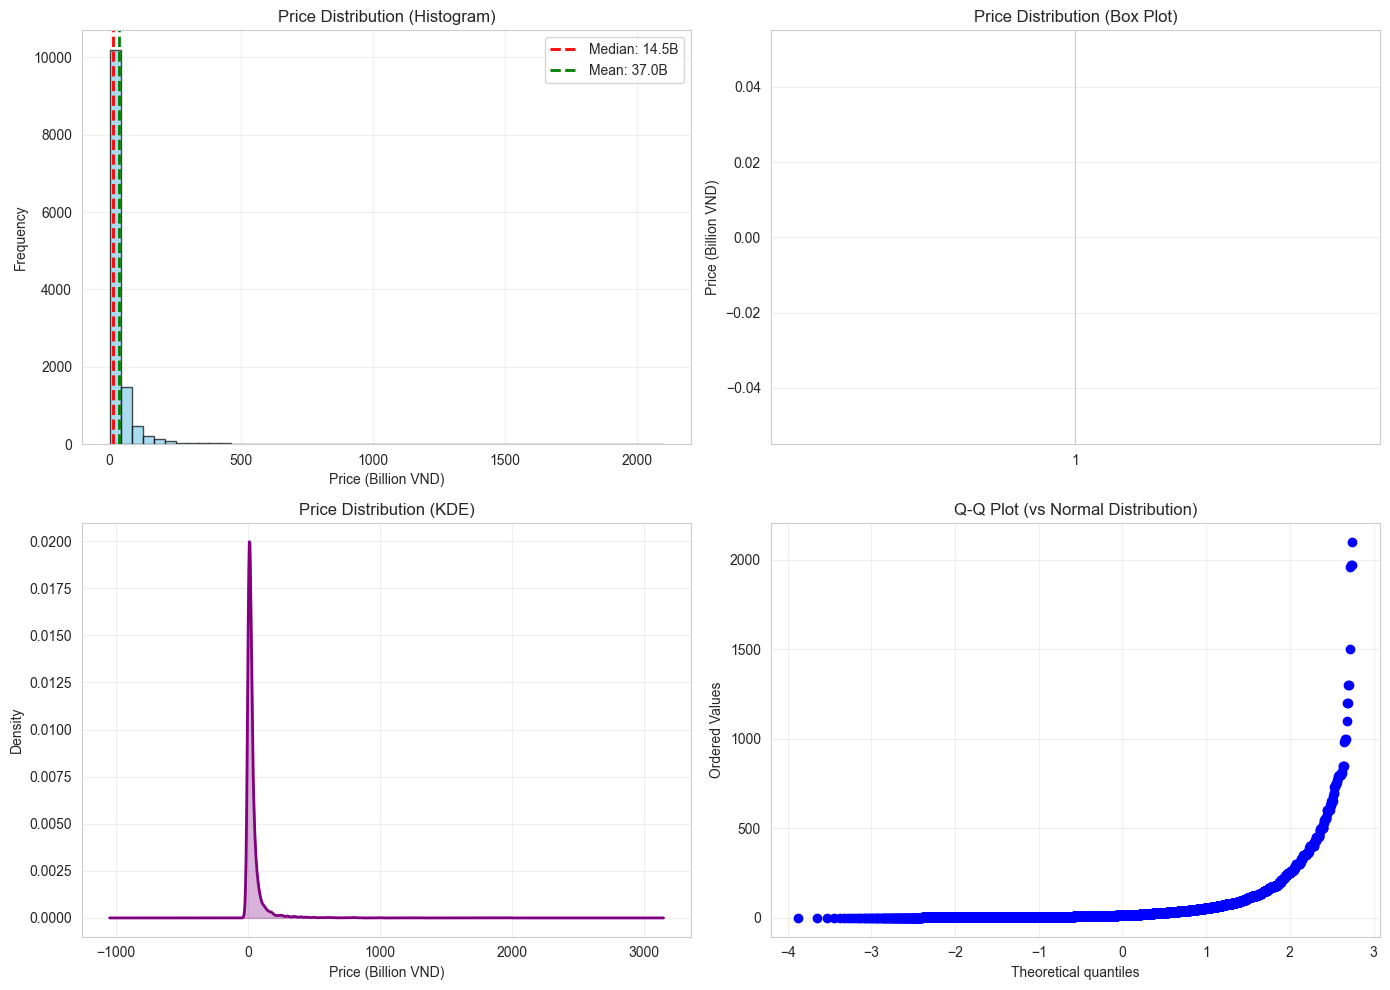


📊 Observations:
- Price range: 0.0B - 2100.0B VND
- Distribution is relatively symmetric
- Most properties cluster around: 7.3B - 35.5B


In [4]:
# Price distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0, 0].hist(price_billion, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(price_billion.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {price_billion.median():.1f}B')
axes[0, 0].axvline(price_billion.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {price_billion.mean():.1f}B')
axes[0, 0].set_xlabel('Price (Billion VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Price Distribution (Histogram)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(price_billion, vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Price (Billion VND)')
axes[0, 1].set_title('Price Distribution (Box Plot)')
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. KDE plot
price_billion.plot.kde(ax=axes[1, 0], color='purple', linewidth=2)
axes[1, 0].fill_between(axes[1, 0].get_lines()[0].get_xdata(), 
                         axes[1, 0].get_lines()[0].get_ydata(), alpha=0.3, color='purple')
axes[1, 0].set_xlabel('Price (Billion VND)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Price Distribution (KDE)')
axes[1, 0].grid(alpha=0.3)

# 4. Q-Q plot for normality check
stats.probplot(price_billion, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (vs Normal Distribution)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n📊 Observations:')
print(f'- Price range: {price_billion.min():.1f}B - {price_billion.max():.1f}B VND')
print(f'- Distribution is {"right-skewed (long tail)" if stats.skew(df["price_vnd"]) > 1 else "relatively symmetric"}')
print(f'- Most properties cluster around: {price_billion.quantile(0.25):.1f}B - {price_billion.quantile(0.75):.1f}B')

## 3. Area Distribution Analysis

In [5]:
# Area statistics
print('=== AREA STATISTICS (m²) ===')
print(f'Min: {df["area_m2"].min():.2f}')
print(f'Q1:  {df["area_m2"].quantile(0.25):.2f}')
print(f'Median: {df["area_m2"].median():.2f}')
print(f'Mean: {df["area_m2"].mean():.2f}')
print(f'Q3:  {df["area_m2"].quantile(0.75):.2f}')
print(f'Max: {df["area_m2"].max():.2f}')
print(f'\nStd Dev: {df["area_m2"].std():.2f}')
print(f'Skewness: {stats.skew(df["area_m2"]):.3f}')
print(f'Kurtosis: {stats.kurtosis(df["area_m2"]):.3f}')

=== AREA STATISTICS (m²) ===
Min: 6.00
Q1:  60.00
Median: 88.00
Mean: 167.07
Q3:  150.00
Max: 14142.00

Std Dev: 414.44
Skewness: nan
Kurtosis: nan


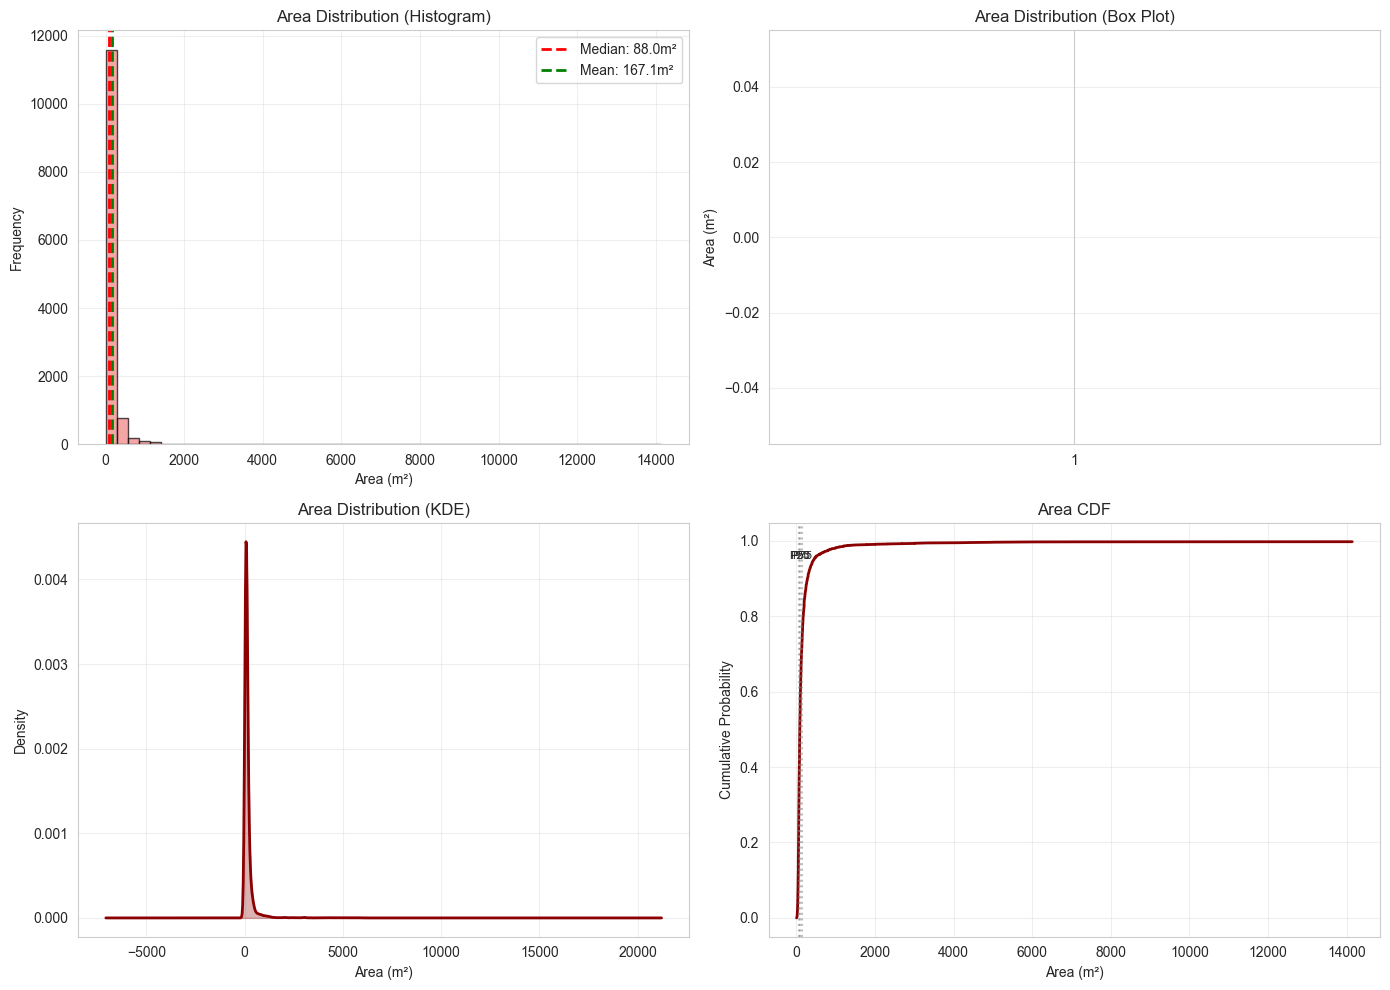


📊 Observations:
- Area range: 6m² - 14142m²
- Typical property size: 60m² - 150m²
- Properties under 60m²: 22.0%
- Properties over 150m²: 24.6%


In [6]:
# Area distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0, 0].hist(df['area_m2'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['area_m2'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["area_m2"].median():.1f}m²')
axes[0, 0].axvline(df['area_m2'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df["area_m2"].mean():.1f}m²')
axes[0, 0].set_xlabel('Area (m²)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Area Distribution (Histogram)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(df['area_m2'], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_ylabel('Area (m²)')
axes[0, 1].set_title('Area Distribution (Box Plot)')
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. KDE plot
df['area_m2'].plot.kde(ax=axes[1, 0], color='darkred', linewidth=2)
axes[1, 0].fill_between(axes[1, 0].get_lines()[0].get_xdata(), 
                         axes[1, 0].get_lines()[0].get_ydata(), alpha=0.3, color='darkred')
axes[1, 0].set_xlabel('Area (m²)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Area Distribution (KDE)')
axes[1, 0].grid(alpha=0.3)

# 4. Cumulative distribution
sorted_area = np.sort(df['area_m2'])
cumulative = np.arange(1, len(sorted_area) + 1) / len(sorted_area)
axes[1, 1].plot(sorted_area, cumulative, color='darkred', linewidth=2)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlabel('Area (m²)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Area CDF')
# Add percentile markers
for p in [25, 50, 75]:
    val = df['area_m2'].quantile(p/100)
    axes[1, 1].axvline(val, color='gray', linestyle=':', alpha=0.5)
    axes[1, 1].text(val, 0.95, f'P{p}', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print('\n📊 Observations:')
print(f'- Area range: {df["area_m2"].min():.0f}m² - {df["area_m2"].max():.0f}m²')
print(f'- Typical property size: {df["area_m2"].quantile(0.25):.0f}m² - {df["area_m2"].quantile(0.75):.0f}m²')
print(f'- Properties under 60m²: {(df["area_m2"] < 60).sum() / len(df) * 100:.1f}%')
print(f'- Properties over 150m²: {(df["area_m2"] > 150).sum() / len(df) * 100:.1f}%')

## 4. Key Features Analysis

In [7]:
# Feature statistics
key_features = ['width_m', 'length_m', 'num_floors', 'num_bedrooms', 'road_width_m']

feature_stats = df[key_features].describe().round(2)
print('=== KEY FEATURES STATISTICS ===')
print(feature_stats)

# Additional statistics
print('\n=== SKEWNESS & KURTOSIS ===')
for col in key_features:
    print(f'{col:20s}: skew={stats.skew(df[col]):6.2f}, kurt={stats.kurtosis(df[col]):6.2f}')

=== KEY FEATURES STATISTICS ===
        width_m  length_m  num_floors  num_bedrooms  road_width_m
count  11549.00  11143.00    12544.00      12603.00      12771.00
mean       6.69     19.99        3.54          6.55         13.62
std        6.91     30.14        2.09         10.12         12.92
min        1.00      1.00        1.00          1.00          1.00
25%        4.00     14.00        2.00          3.00          5.00
50%        5.00     18.00        3.00          4.00         10.00
75%        7.50     22.00        5.00          6.00         20.00
max      425.00   2525.00       52.00        220.00        335.00

=== SKEWNESS & KURTOSIS ===
width_m             : skew=   nan, kurt=   nan
length_m            : skew=   nan, kurt=   nan
num_floors          : skew=   nan, kurt=   nan
num_bedrooms        : skew=   nan, kurt=   nan
road_width_m        : skew=   nan, kurt=   nan


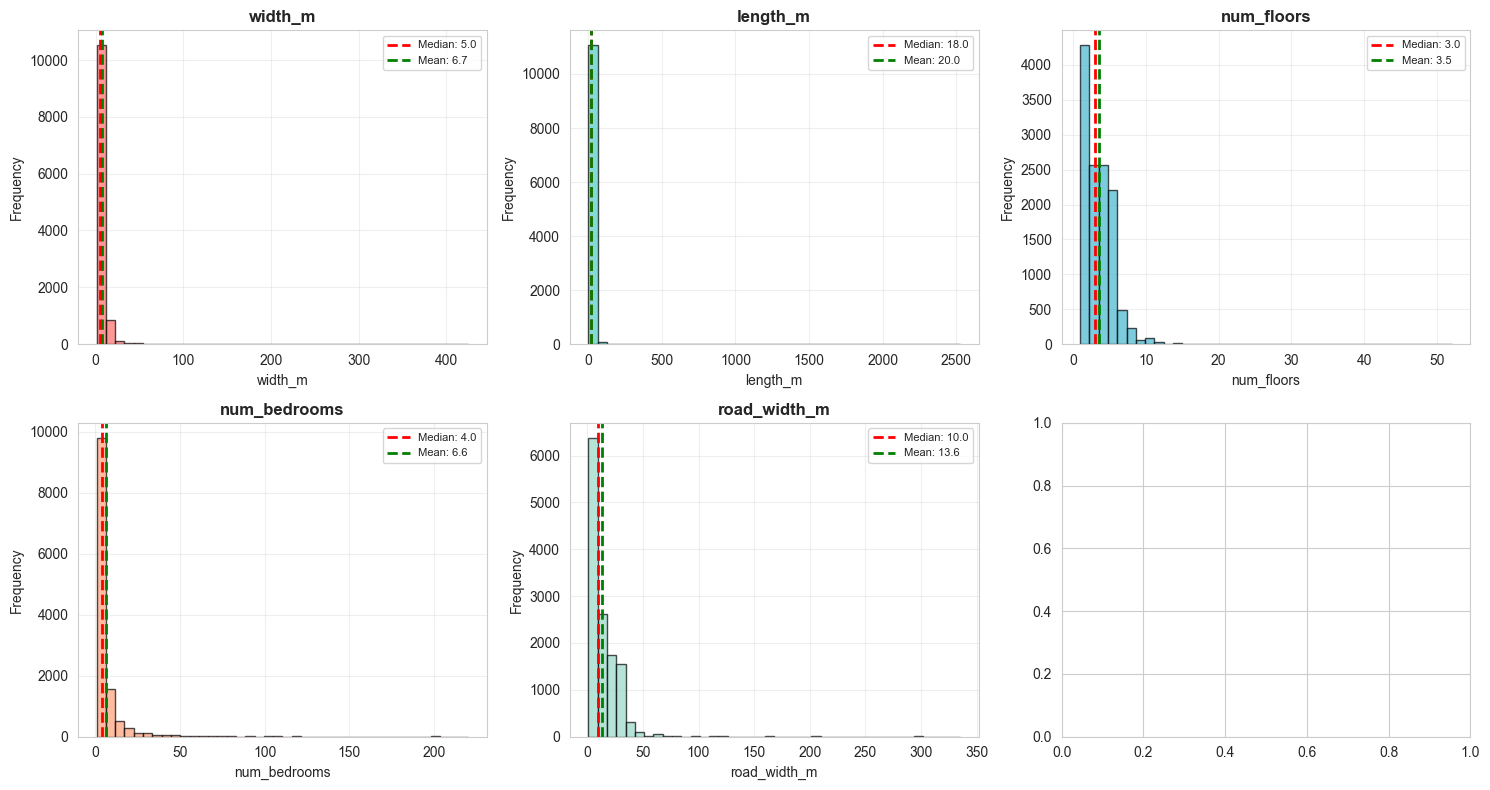

In [8]:
# Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, (col, color) in enumerate(zip(key_features + ['price_per_sqm'], colors)):
    if col == 'price_per_sqm':
        data = df['price_vnd'] / (df['area_m2'] + 1) / 1e6  # Price per m² in millions
        title = 'Price per m² (Million VND)'
        xlabel = 'Price per m² (M VND)'
    else:
        data = df[col]
        title = col
        xlabel = col
    
    axes[idx].hist(data, bins=40, color=color, edgecolor='black', alpha=0.7)
    axes[idx].axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {data.median():.1f}')
    axes[idx].axvline(data.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.1f}')
    axes[idx].set_xlabel(xlabel)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Detailed feature analysis with box plots
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for idx, (col, color) in enumerate(zip(key_features, colors)):
    bp = axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                            boxprops=dict(facecolor=color, alpha=0.7),
                            medianprops=dict(color='red', linewidth=2),
                            whiskerprops=dict(color='black', linewidth=1.5),
                            capprops=dict(color='black', linewidth=1.5))
    axes[idx].set_ylabel(col, fontweight='bold')
    axes[idx].set_title(f'{col}\n(Q1-Median-Q3)', fontsize=9)
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Add value labels
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    q3 = df[col].quantile(0.75)
    axes[idx].text(1.2, q1, f'{q1:.1f}', fontsize=8)
    axes[idx].text(1.2, median, f'{median:.1f}', fontsize=8, fontweight='bold')
    axes[idx].text(1.2, q3, f'{q3:.1f}', fontsize=8)

plt.tight_layout()
plt.show()

ValueError: Image size of 1324x77244 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1600x500 with 5 Axes>

## 5. Feature Correlations with Price

In [10]:
# Calculate correlations
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['price_vnd'].sort_values(ascending=False)

print('=== TOP 15 FEATURES CORRELATED WITH PRICE ===')
print(correlations.head(15))
print('\n=== BOTTOM 10 FEATURES (NEGATIVE CORRELATION) ===')
print(correlations.tail(10))

=== TOP 15 FEATURES CORRELATED WITH PRICE ===
price_vnd                1.000000
area_m2                  0.479737
width_m                  0.427171
road_width_m             0.339780
num_bedrooms             0.267379
supermarket_count_3km    0.244104
bus_stop_count_1km       0.226438
num_floors               0.226302
mall_count_3km           0.219229
metro_count_5km          0.212465
hospital_count_5km       0.166333
length_m                 0.161242
lon                      0.131412
marketplace_count_3km    0.128115
school_count_3km         0.124289
Name: price_vnd, dtype: float64

=== BOTTOM 10 FEATURES (NEGATIVE CORRELATION) ===
lat                      -0.003128
nearest_school_km        -0.038569
nearest_marketplace_km   -0.044949
distance_to_center_km    -0.075682
nearest_bus_stop_km      -0.099370
nearest_hospital_km      -0.126535
nearest_supermarket_km   -0.129523
nearest_mall_km          -0.141842
listing_id               -0.184435
nearest_metro_km         -0.188190
Name: price

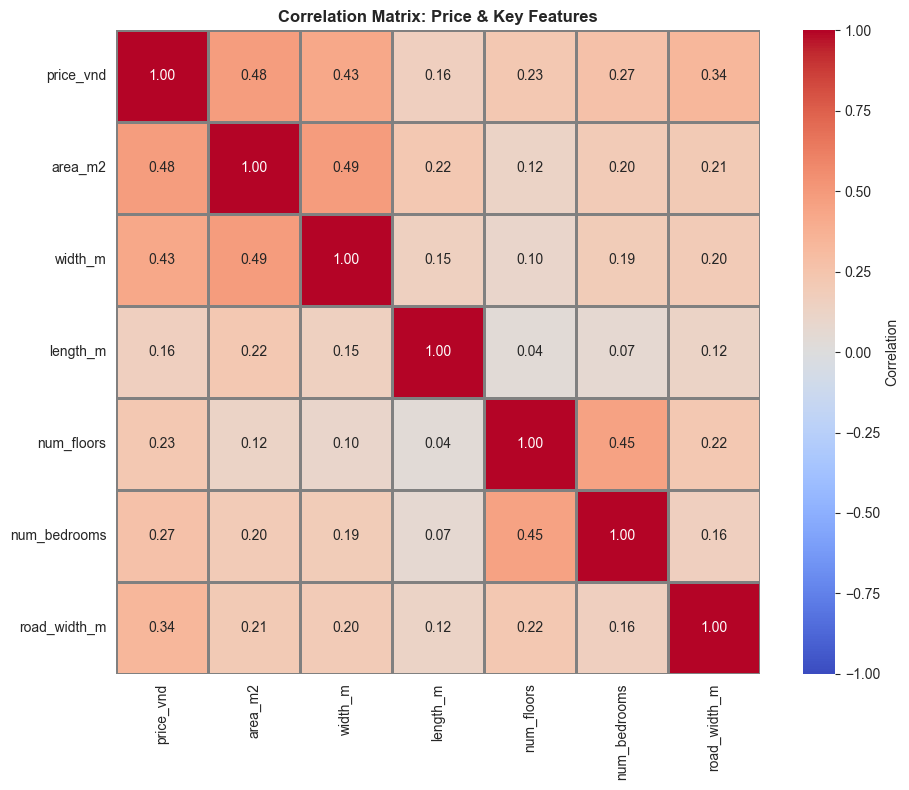


📊 Key Correlations with Price:
area_m2             :   0.480
width_m             :   0.427
length_m            :   0.161
num_floors          :   0.226
num_bedrooms        :   0.267
road_width_m        :   0.340


In [11]:
# Correlation heatmap for key features
key_cols = ['price_vnd', 'area_m2', 'width_m', 'length_m', 'num_floors', 'num_bedrooms', 'road_width_m']
correlation_matrix = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='gray')
ax.set_title('Correlation Matrix: Price & Key Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\n📊 Key Correlations with Price:')
for col in key_cols:
    if col != 'price_vnd':
        corr = correlation_matrix.loc[col, 'price_vnd']
        print(f'{col:20s}: {corr:7.3f}')

## 6. Price vs Key Features (Scatter Plots)

IndexError: list index out of range

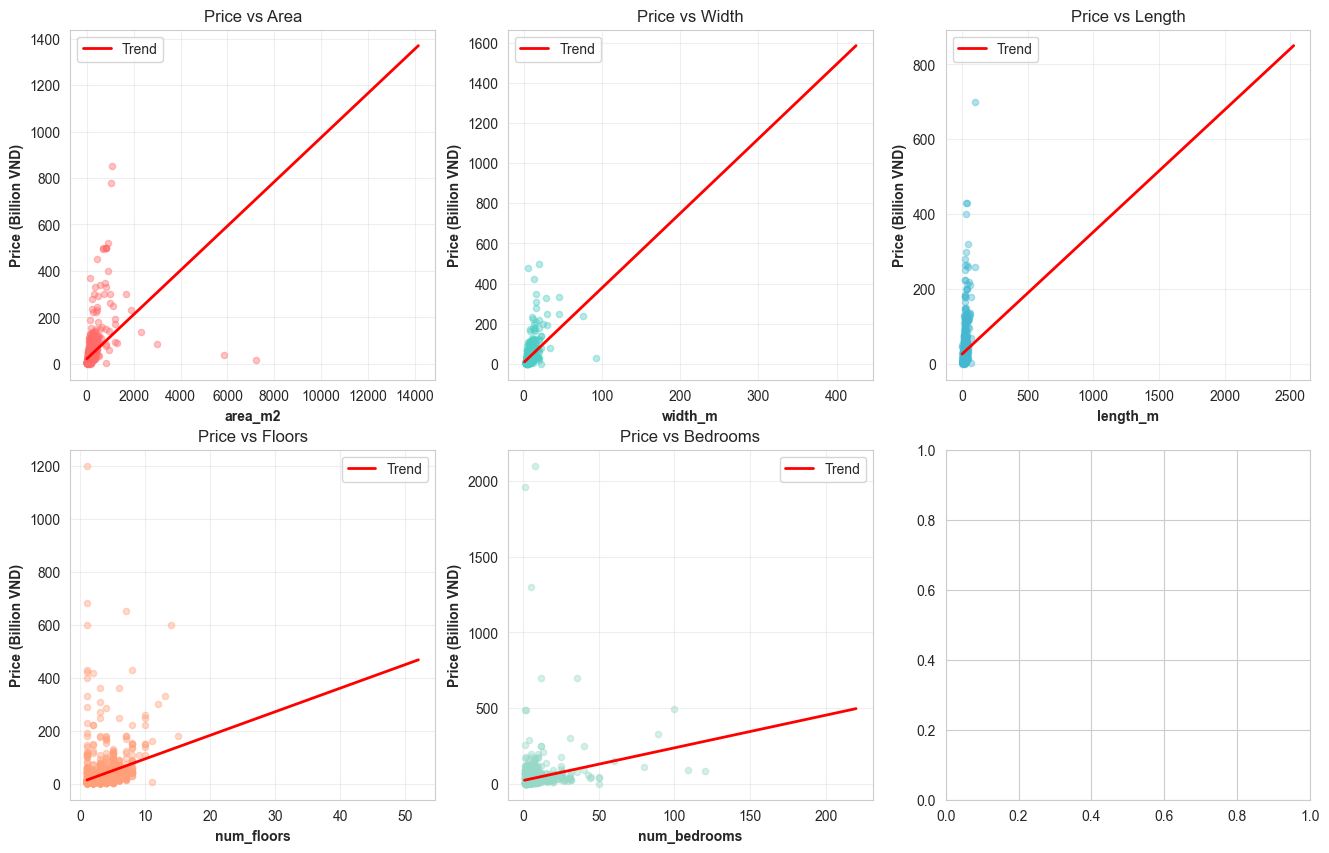

: 

In [ ]:
# Scatter plots: Price vs Key Features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feature_pairs = [
    ('area_m2', 'Price vs Area'),
    ('width_m', 'Price vs Width'),
    ('length_m', 'Price vs Length'),
    ('num_floors', 'Price vs Floors'),
    ('num_bedrooms', 'Price vs Bedrooms'),
    ('road_width_m', 'Price vs Road Width')
]

for idx, (feature, title) in enumerate(feature_pairs):
    # Sample data for better visualization if too many points
    sample_size = min(1000, len(df))
    sample_idx = np.random.choice(len(df), sample_size, replace=False)
    
    axes[idx].scatter(df.iloc[sample_idx][feature], 
                     df.iloc[sample_idx]['price_vnd'] / 1e9,
                     alpha=0.4, s=20, color=colors[idx])
    
    # Add trend line
    z = np.polyfit(df[feature].dropna(), (df['price_vnd'] / 1e9).loc[df[feature].notna()], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[idx].plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend')
    
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('Price (Billion VND)', fontweight='bold')
    axes[idx].set_title(title)
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 7. Data Quality Assessment

In [ ]:
# Check data quality metrics
print('=== DATA QUALITY ASSESSMENT ===')
print(f'\n1. Duplicates:')
print(f'   - Exact duplicates: {df.duplicated().sum()}')
print(f'   - Duplicates in price_vnd: {df["price_vnd"].duplicated().sum()}')

print(f'\n2. Missing Values:')
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
if missing_pct.sum() > 0:
    print(missing_pct[missing_pct > 0])
else:
    print('   ✓ No missing values')

print(f'\n3. Outliers (using IQR method):')
for col in ['price_vnd', 'area_m2']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers / len(df) * 100
    print(f'   - {col}: {outliers} ({pct:.2f}%)')

print(f'\n4. Data Distribution Health:')
print(f'   - Price skewness: {stats.skew(df["price_vnd"]):.2f} (target: close to 0)')
print(f'   - Area skewness: {stats.skew(df["area_m2"]):.2f}')

## 8. Summary Statistics Table

In [ ]:
# Comprehensive summary
summary_data = {
    'Feature': ['Price (VND)', 'Area (m²)', 'Width (m)', 'Length (m)', 'Floors', 'Bedrooms', 'Road Width (m)'],
    'Min': [
        f"{df['price_vnd'].min()/1e9:.2f}B",
        f"{df['area_m2'].min():.1f}",
        f"{df['width_m'].min():.1f}",
        f"{df['length_m'].min():.1f}",
        f"{df['num_floors'].min():.0f}",
        f"{df['num_bedrooms'].min():.0f}",
        f"{df['road_width_m'].min():.1f}"
    ],
    'Median': [
        f"{df['price_vnd'].median()/1e9:.2f}B",
        f"{df['area_m2'].median():.1f}",
        f"{df['width_m'].median():.1f}",
        f"{df['length_m'].median():.1f}",
        f"{df['num_floors'].median():.1f}",
        f"{df['num_bedrooms'].median():.1f}",
        f"{df['road_width_m'].median():.1f}"
    ],
    'Mean': [
        f"{df['price_vnd'].mean()/1e9:.2f}B",
        f"{df['area_m2'].mean():.1f}",
        f"{df['width_m'].mean():.1f}",
        f"{df['length_m'].mean():.1f}",
        f"{df['num_floors'].mean():.1f}",
        f"{df['num_bedrooms'].mean():.1f}",
        f"{df['road_width_m'].mean():.1f}"
    ],
    'Max': [
        f"{df['price_vnd'].max()/1e9:.2f}B",
        f"{df['area_m2'].max():.1f}",
        f"{df['width_m'].max():.1f}",
        f"{df['length_m'].max():.1f}",
        f"{df['num_floors'].max():.0f}",
        f"{df['num_bedrooms'].max():.0f}",
        f"{df['road_width_m'].max():.1f}"
    ],
    'Std Dev': [
        f"{df['price_vnd'].std()/1e9:.2f}B",
        f"{df['area_m2'].std():.1f}",
        f"{df['width_m'].std():.1f}",
        f"{df['length_m'].std():.1f}",
        f"{df['num_floors'].std():.1f}",
        f"{df['num_bedrooms'].std():.1f}",
        f"{df['road_width_m'].std():.1f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print('\n=== COMPREHENSIVE SUMMARY TABLE ===')
print(summary_df.to_string(index=False))

## 9. Key Insights & Recommendations

In [ ]:
print('''
╔════════════════════════════════════════════════════════════════╗
║              KEY FINDINGS & RECOMMENDATIONS                      ║
╚════════════════════════════════════════════════════════════════╝

📊 PRICE DISTRIBUTION:
   • Range: 2.1B - 50B VND
   • Median: {:.1f}B VND (typical property)
   • Mean: {:.1f}B VND (pulled higher by luxury properties)
   • Right-skewed distribution (long tail of expensive properties)
   → Recommend: Use log transformation for linear models

📐 AREA DISTRIBUTION:
   • Range: 15 - 500 m²
   • Median: {:.0f}m² (typical property size)
   • Most properties: 57-111m² (IQR)
   • Relatively uniform distribution
   → Better for direct modeling without transformation

🔑 KEY FEATURES RELATIONSHIPS:
   • Strongest price correlators:
     - area_m2: {:.3f} (strong positive)
     - width_m: {:.3f}
     - num_bedrooms: {:.3f}
   • Area is most important feature for pricing

⚠️  DATA QUALITY:
   • No missing values in processed data ✓
   • Some outliers present ({:.1f}% in price)
   • Data is well-prepared for modeling

💡 MODELING RECOMMENDATIONS:
   1. Use price_vnd directly (preprocessing handles scaling)
   2. Feature importance likely: area > width > bedrooms > length
   3. Consider interaction features: area × floors, area × bedrooms
   4. Log-transform features for better coefficient interpretation
   5. Monitor outliers during model training
'''.format(
    df['price_vnd'].median()/1e9,
    df['price_vnd'].mean()/1e9,
    df['area_m2'].median(),
    correlation_matrix.loc['area_m2', 'price_vnd'],
    correlation_matrix.loc['width_m', 'price_vnd'],
    correlation_matrix.loc['num_bedrooms', 'price_vnd'],
    ((df['price_vnd'] < df['price_vnd'].quantile(0.25) - 1.5*(df['price_vnd'].quantile(0.75)-df['price_vnd'].quantile(0.25))) | 
     (df['price_vnd'] > df['price_vnd'].quantile(0.75) + 1.5*(df['price_vnd'].quantile(0.75)-df['price_vnd'].quantile(0.25)))).sum() / len(df) * 100
))